In [20]:
from IPython import display
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display as mostrar
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# 1. Cargar dataset raw
# ------------------------------------------------------------

RAW_PATH = "../Data/NASA_Exoplanet_Archive_Data.csv"

df_raw = pd.read_csv(RAW_PATH)

TARGET = "pl_bmasse"

print("Dataset cargado correctamente.")
print(f"Filas originales: {df_raw.shape[0]}")

Dataset cargado correctamente.
Filas originales: 36418


In [21]:
# ------------------------------------------------------------
# 2. Filtrado Inicial
# ------------------------------------------------------------

df = df_raw[df_raw["default_flag"] == 1].copy()

# Para entrenar necesitamos masa conocida
df = df.dropna(subset=[TARGET])

df = df.reset_index(drop=True)

print(f"Filas después de filtros básicos: {len(df)}")
print(f"Planetas únicos: {df['pl_name'].nunique()}")

print("\nResumen del target:")
print(df[TARGET].describe())

Filas después de filtros básicos: 2706
Planetas únicos: 2706

Resumen del target:
count   2706.0000
mean     767.9173
std     1461.4409
min        0.0200
25%       13.6575
50%      187.5197
75%      731.0053
max     9534.9000
Name: pl_bmasse, dtype: float64


Distribución de pl_bmasse


count   2706.0000
mean     767.9173
std     1461.4409
min        0.0200
25%       13.6575
50%      187.5197
75%      731.0053
max     9534.9000
Name: pl_bmasse, dtype: float64

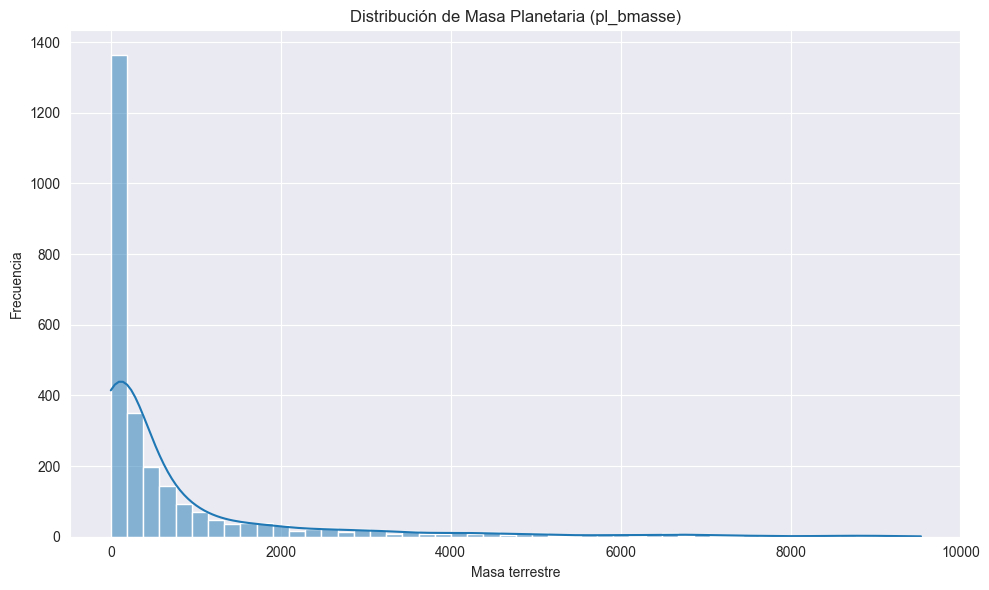

In [22]:
# ------------------------------------------------------------
# 3. Distribución de la Variable Objetivo
# ------------------------------------------------------------

print("Distribución de pl_bmasse")

mostrar(df[TARGET].describe())

plt.figure(figsize=(10,6))

sns.histplot(
    df[TARGET],
    bins=50,
    kde=True
)

plt.title("Distribución de Masa Planetaria (pl_bmasse)")
plt.xlabel("Masa terrestre")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------
# 4. Mitigación de Data Leakage
# ------------------------------------------------------------

id_cols              = ["pl_name", "hostname"]
metadata_cols        = ["pl_refname", "st_refname", "sy_refname", "rowupdate",
                        "pl_pubdate", "releasedate", "soltype"]
discovery_proc_cols  = ["disc_year", "disc_facility"]
coord_text_cols      = ["rastr", "decstr"]
technical_cols       = ["default_flag", "ttv_flag", "pl_bmassprov", "st_metratio"]
redundant_unit_cols  = ["pl_radj", "pl_bmassj"]
error_lim_cols       = [col for col in df.columns if col.endswith(("err1", "err2", "lim"))]

cols_to_drop = (id_cols + metadata_cols + discovery_proc_cols +
                coord_text_cols + technical_cols + redundant_unit_cols + error_lim_cols)

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")
print(f"Columnas eliminadas: {len(cols_to_drop)}")
print(f"Shape después de mitigación: {df.shape}")

Columnas eliminadas: 69
Shape después de mitigación: (2706, 22)


Columnas con valores nulos:


,nulos,porcentaje_nulos
pl_insol,2215,81.8551
st_spectype,1676,61.9364
pl_eqt,1667,61.6038
pl_rade,1400,51.7369
st_logg,867,32.0399
st_met,831,30.7095
st_rad,703,25.9793
st_teff,617,22.8012
pl_orbeccen,559,20.6578
pl_orbsmax,333,12.3060


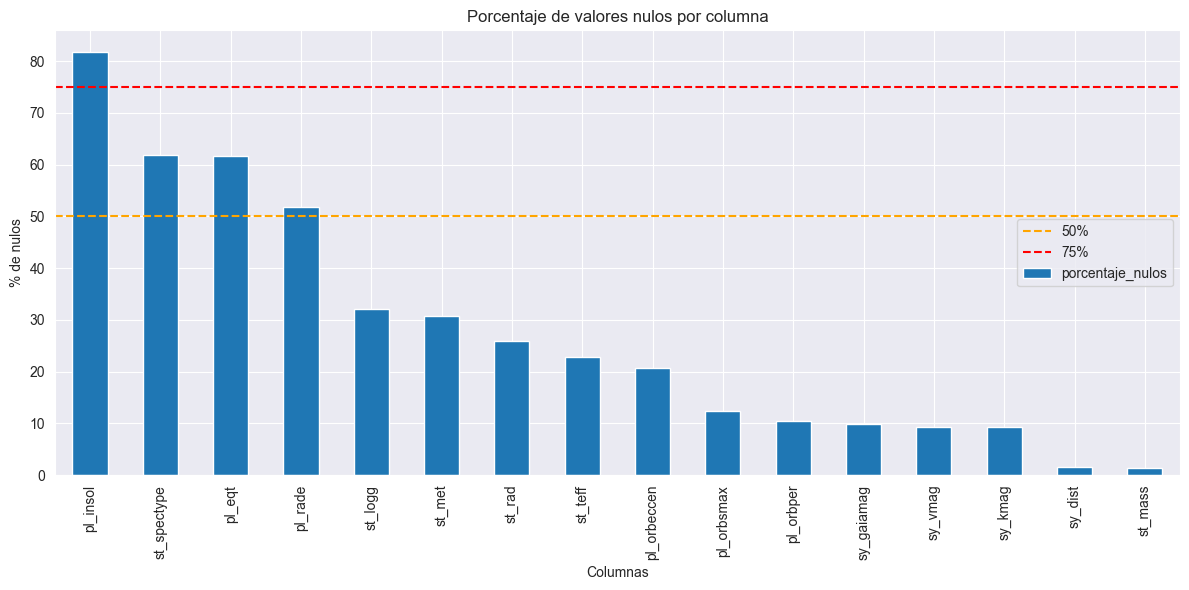

In [24]:
# ------------------------------------------------------------
# 5. Analizar nulos
# ------------------------------------------------------------

null_summary = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": df.isnull().mean() * 100
}).sort_values("porcentaje_nulos", ascending=False)

null_summary_nonzero = null_summary[null_summary["nulos"] > 0]

print("Columnas con valores nulos:")
mostrar(null_summary_nonzero)

plt.figure(figsize=(12, 6))
null_summary_nonzero["porcentaje_nulos"].plot(kind="bar")
plt.axhline(50, linestyle="--", label="50%", color="orange")
plt.axhline(75, linestyle="--", label="75%", color="red")
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("% de nulos")
plt.legend()
plt.tight_layout()
plt.show()

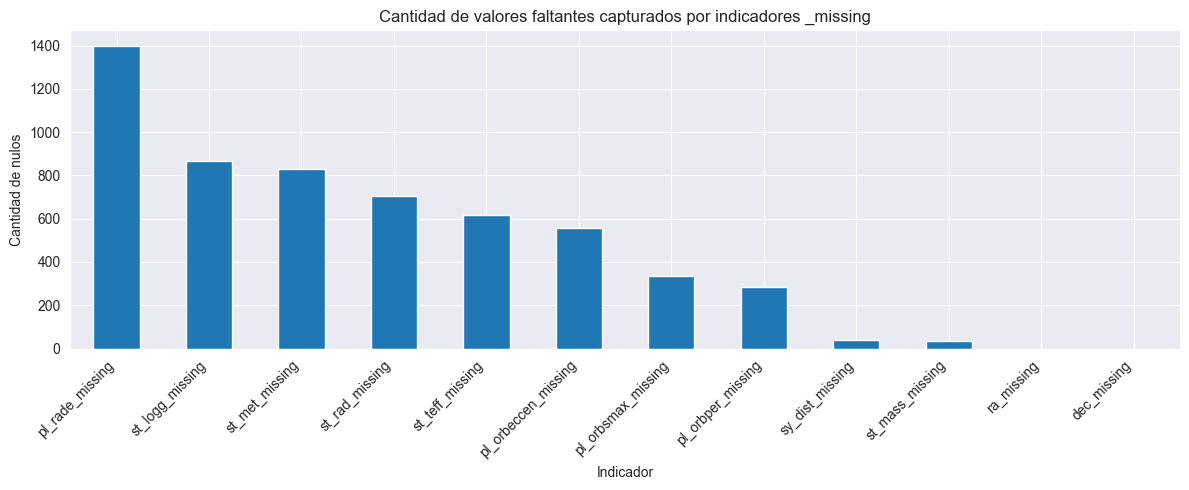

In [25]:
# ------------------------------------------------------------
# 6. Capturar Ausencia Informativa (_missing)
# ------------------------------------------------------------

missing_signal_cols = [
    "pl_rade", "pl_orbper", "pl_orbsmax", "pl_orbeccen",
    "st_teff", "st_rad", "st_mass", "st_met", "st_logg", "sy_dist", "ra", "dec"
]
missing_signal_cols = [col for col in missing_signal_cols if col in df.columns]

for col in missing_signal_cols:
    df[f"{col}_missing"] = df[col].isnull().astype(int)

missing_indicators = [f"{col}_missing" for col in missing_signal_cols]
missing_counts = df[missing_indicators].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing_counts.plot(kind="bar")
plt.title("Cantidad de valores faltantes capturados por indicadores _missing")
plt.xlabel("Indicador")
plt.ylabel("Cantidad de nulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# ------------------------------------------------------------
# 7. Eliminar columnas con nulos excesivos (>75%)
# ------------------------------------------------------------

high_null_cols   = null_summary[null_summary["porcentaje_nulos"] > 75].index.tolist()
protected_cols   = [TARGET] + missing_signal_cols + missing_indicators
cols_to_drop_hn  = [col for col in high_null_cols if col not in protected_cols]

df = df.drop(columns=cols_to_drop_hn, errors="ignore")
print(f"Columnas eliminadas por nulos excesivos: {cols_to_drop_hn}")
print(f"Shape final de datos únicos: {df.shape}")

Columnas eliminadas por nulos excesivos: ['pl_insol']
Shape final de datos únicos: (2706, 33)


In [27]:
# ------------------------------------------------------------
# 8. Consistencia Física
# ------------------------------------------------------------

positive_cols = ["pl_rade", "pl_bmasse", "pl_orbper", "pl_orbsmax",
                 "st_teff", "st_rad", "st_mass", "sy_dist"]
positive_cols = [col for col in positive_cols if col in df.columns]

# Excentricidad orbital debe estar en [0, 1]
if "pl_orbeccen" in df.columns:
    df.loc[(df["pl_orbeccen"] < 0) | (df["pl_orbeccen"] > 1), "pl_orbeccen"] = np.nan

invalid_summary = []
for col in positive_cols:
    invalid_count = (df[col] < 0).sum()
    invalid_summary.append({"columna": col, "valores_negativos": invalid_count})
    if invalid_count > 0:
        df.loc[df[col] < 0, col] = np.nan

mostrar(pd.DataFrame(invalid_summary))
print("Consistencia física validada.")

,columna,valores_negativos
0,pl_rade,0
1,pl_bmasse,0
2,pl_orbper,0
3,pl_orbsmax,0
4,st_teff,0
5,st_rad,0
6,st_mass,0
7,sy_dist,0


Consistencia física validada.


In [28]:
# ------------------------------------------------------------
# 9. Transformación Logarítmica
# ------------------------------------------------------------

skewed_cols = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "sy_dist"
]

skewed_cols = [c for c in skewed_cols if c in df.columns]

df_before_processing = df.copy()

for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Transformación logarítmica del target
df[TARGET] = np.log1p(df[TARGET])

print(f"Log-transform aplicado a: {skewed_cols}")
print(f"Log-transform aplicado al target: {TARGET}")

# En el Bloque 9 del ETL de Regresión hiciste esto: df[TARGET] = np.log1p(df[TARGET]).
# Esto es una práctica de Ciencia de Datos avanzadísima para que el modelo funcione mejor cuando la variable tiene valores muy dispares (planetas enanos vs. gigantes gaseosos).
#
# ¿Qué pasa con esto? Que los resultados que te va a dar el MAE y el RMSE en la evaluación final no están en "Masas Terrestres", están en "Logaritmo de Masas Terrestres".
#
# Si el MAE te da "0.5", no significa que le erraste por media Tierra, significa que le erraste por el exponencial de 0.5.
#
# Si un profesor te lo pregunta en la exposición, tenés que responder: > "Profesor, cabe destacar que nosotros aplicamos una transformación logarítmica a la variable objetivo (pl_bmasse) para normalizar su distribución. Por lo tanto, el MAE y RMSE que vemos en pantalla están en escala logarítmica. Si quisiéramos ver el error en masas terrestres reales, deberíamos aplicar la función matemática inversa (exponencial) a las predicciones".

Log-transform aplicado a: ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'sy_dist']
Log-transform aplicado al target: pl_bmasse


Train: 2164 filas
Test : 542 filas


/var/folders/9k/22p813p5179dk7tclr_33j5m0000gn/T/ipykernel_27124/1891250165.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


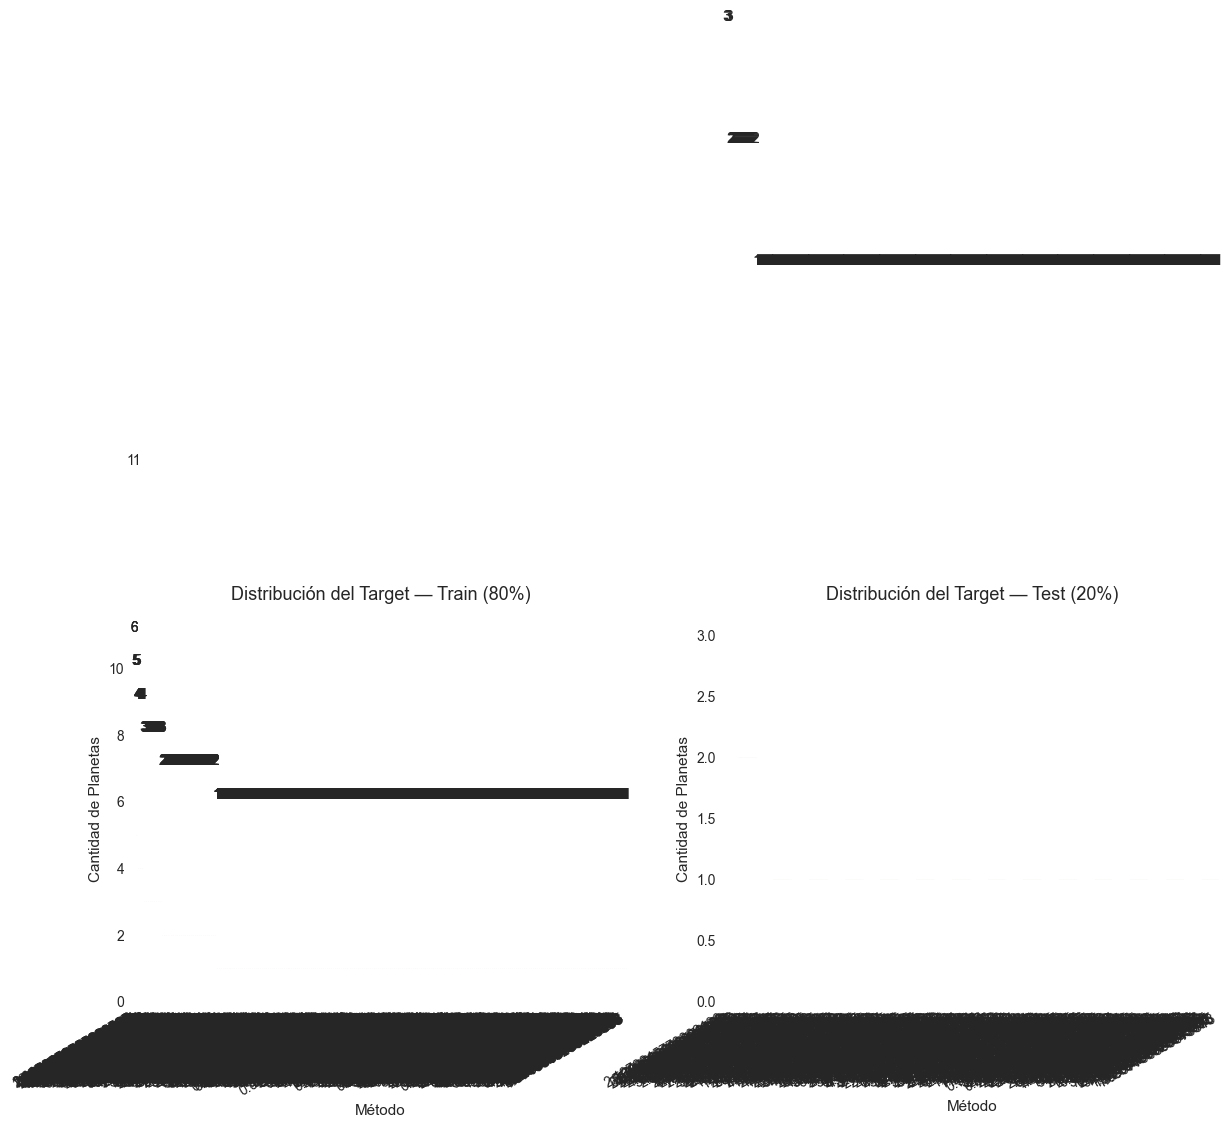

In [29]:
# ------------------------------------------------------------
# 10. Train Test Split
# ------------------------------------------------------------

X = df.drop(columns=[TARGET])

y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test : {X_test.shape[0]} filas")

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, titulo in zip(
    axes,
    [y_train.value_counts(), y_test.value_counts()],
    ["Train (80%)", "Test (20%)"]
):
    counts.plot(kind='bar', ax=ax, color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
    ax.set_title(f"Distribución del Target — {titulo}", fontsize=13, pad=12)
    ax.set_xlabel("Método", fontsize=11)
    ax.set_ylabel("Cantidad de Planetas", fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xticklabels(counts.index, ha='right')
    for i, v in enumerate(counts):
        ax.text(i, v + 5, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [30]:
# ------------------------------------------------------------
# 11. Winsorización — fit en train, transform en ambos
# ------------------------------------------------------------
# Recorta valores extremos al percentil 1 y 99 de cada columna.
# Esto elimina las concentraciones extremas que SMOTE luego
# amplifica al generar muestras sintéticas en esas zonas.
# Se fitea SOLO en train para evitar leakage.
# ------------------------------------------------------------

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
winsorize_cols = [col for col in numeric_cols if not col.endswith("_missing")]

# Aprender límites solo en train
lower_bounds = X_train[winsorize_cols].quantile(0.01)
upper_bounds = X_train[winsorize_cols].quantile(0.99)

# Aplicar a train y test
X_train[winsorize_cols] = X_train[winsorize_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)
X_test[winsorize_cols] = X_test[winsorize_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)

print(f"Winsorización aplicada a {len(winsorize_cols)} columnas (p1-p99).")
print("Filas eliminadas: 0 — solo se recortan los valores extremos.")

Winsorización aplicada a 18 columnas (p1-p99).
Filas eliminadas: 0 — solo se recortan los valores extremos.


In [31]:
# ------------------------------------------------------------
# 12. Imputación KNN — fit en train, transform en ambos
# ------------------------------------------------------------
# Las columnas _missing (0/1) no tienen NaNs: se excluyen del
# imputer para no distorsionar las distancias KNN.
# ------------------------------------------------------------

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_no_missing = [col for col in numeric_cols if not col.endswith("_missing")]

imputer = KNNImputer(n_neighbors=5)
X_train[numeric_no_missing] = imputer.fit_transform(X_train[numeric_no_missing])  # fit + transform
X_test[numeric_no_missing]  = imputer.transform(X_test[numeric_no_missing])        # solo transform

# Categóricas: imputar con 'Unknown'
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown")
    X_test[col]  = X_test[col].fillna("Unknown")

print("Imputación KNN completada (sin leakage).")

Imputación KNN completada (sin leakage).


In [32]:
# ------------------------------------------------------------
# 13. Codificación de Variables Categóricas
# ------------------------------------------------------------

cat_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = X_test[col].astype(str)

    unseen = ~X_test[col].isin(le.classes_)

    if unseen.any():
        X_test.loc[unseen, col] = le.classes_[0]

    X_test[col] = le.transform(X_test[col])

    encoders[col] = le

print("Codificación completada.")

Codificación completada.


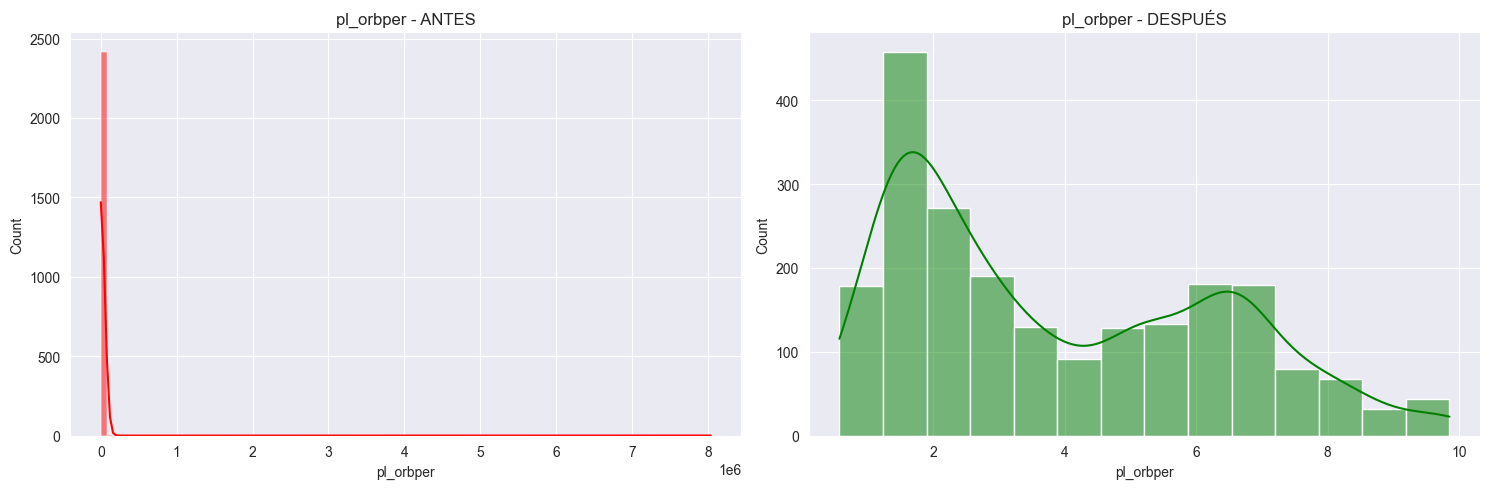

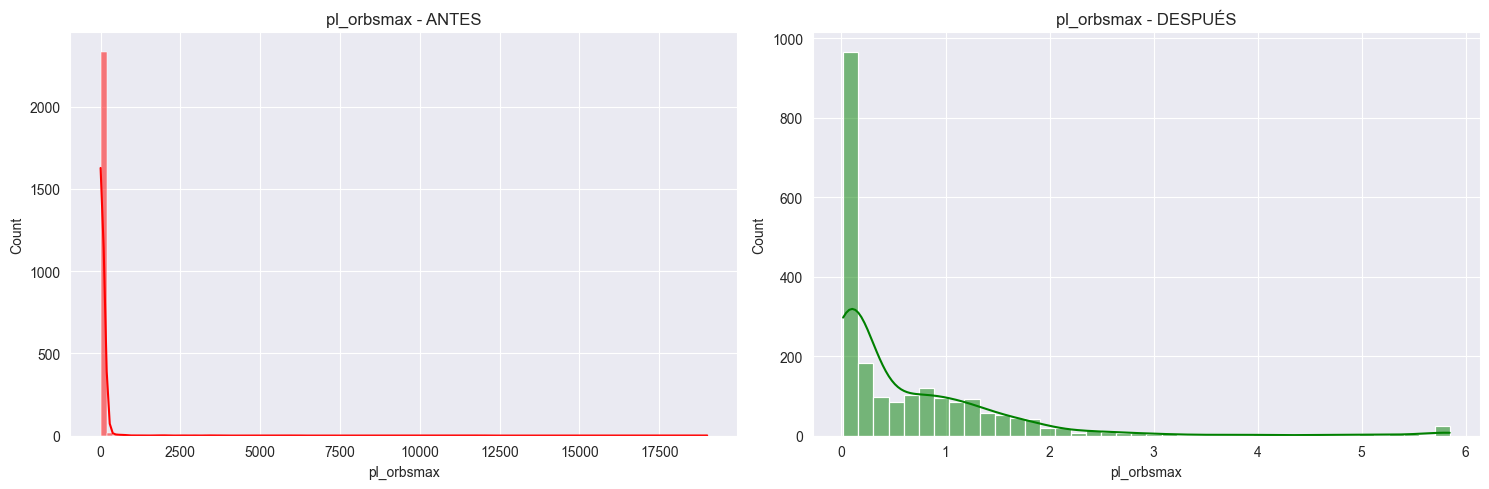

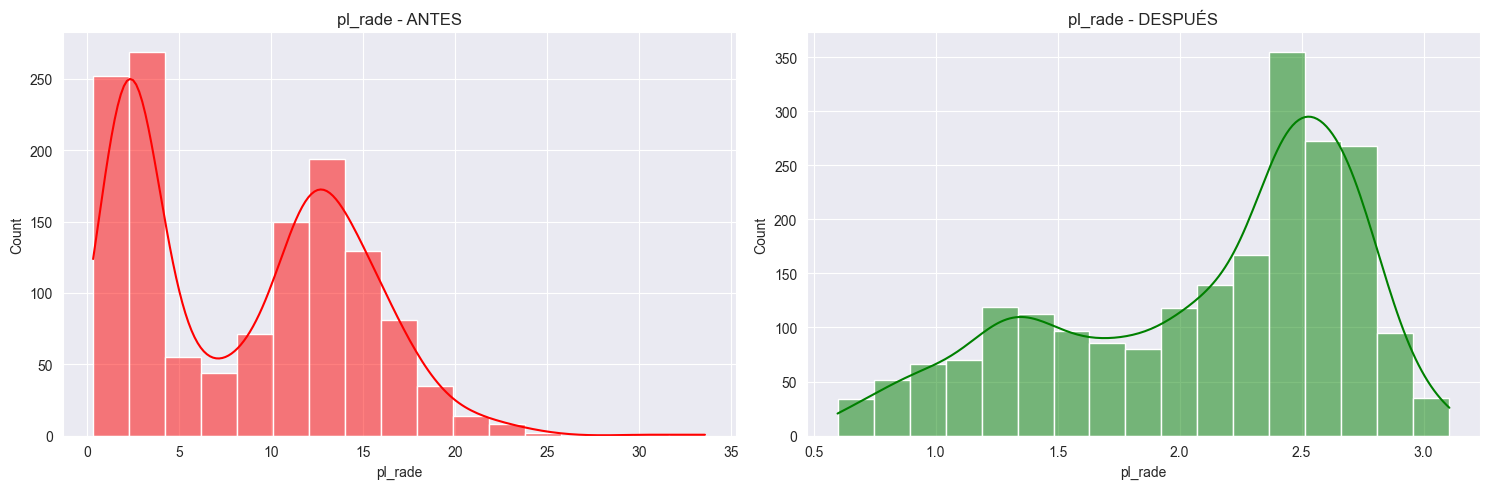


ETL finalizado correctamente.


In [33]:
# ------------------------------------------------------------
# 14. Visualización Comparativa
# ------------------------------------------------------------

cols_to_plot = [
    c for c in [
        "pl_orbper",
        "pl_orbsmax",
        "pl_rade"
    ]
    if c in X_train.columns
]

for col in cols_to_plot:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15,5)
    )

    sns.histplot(
        df_before_processing[col].dropna(),
        kde=True,
        ax=axes[0],
        color="red"
    )

    axes[0].set_title(
        f"{col} - ANTES"
    )

    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[1],
        color="green"
    )

    axes[1].set_title(
        f"{col} - DESPUÉS"
    )

    plt.tight_layout()
    plt.show()

print("\nETL finalizado correctamente.")

In [34]:
# ------------------------------------------------------------
# 15. Exportar datasets de REGRESIÓN
# ------------------------------------------------------------
processed_dir = "../Data/processed"
os.makedirs(processed_dir, exist_ok=True)

X_train.to_csv(os.path.join(processed_dir, "X_train_reg.csv"), index=False)
X_test.to_csv(os.path.join(processed_dir, "X_test_reg.csv"), index=False)
y_train.to_csv(os.path.join(processed_dir, "y_train_reg.csv"), index=False)
y_test.to_csv(os.path.join(processed_dir, "y_test_reg.csv"), index=False)

print("Datasets de regresión exportados correctamente.")

Datasets de regresión exportados correctamente.
